In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# FORWARD 1D SCHLUMBERGER

def forward(res, thick, ab2):
    lays = len(res) - 1
    LOG = np.log(10.0)
    COUNTER = 1 + (2 * 13 - 2)
    UP = np.exp(0.5 * LOG / 4.438)

    rho_app = np.zeros_like(ab2, dtype=float)

    for k, ab in enumerate(ab2):
        up = ab * np.exp(-10 * LOG / 4.438)
        ti = np.zeros(COUNTER)

        for ii in range(COUNTER):
            ti1 = res[lays]
            lay = lays
            while lay > 0:
                lay -= 1
                tan_h = np.tanh(thick[lay] / up)
                ti1 = (ti1 + res[lay] * tan_h) / (1 + ti1 * tan_h / res[lay])
            ti[ii] = ti1
            up *= UP

        res_a = (
            105 * ti[0] - 262 * ti[2] + 416 * ti[4] - 746 * ti[6] +
            1605 * ti[8] - 4390 * ti[10] + 13396 * ti[12] -
            27841 * ti[14] + 16448 * ti[16] + 8183 * ti[18] +
            2525 * ti[20] + 336 * ti[22] + 225 * ti[24]
        )
        rho_app[k] = res_a / 1e4

    return rho_app

In [3]:
# RANDOM MODEL

def random_model(min_layers=3, max_layers=8, min_depth=20, max_depth=100):
    n_layers = np.random.randint(min_layers, max_layers + 1)
    total_depth = np.random.uniform(min_depth, max_depth)

    resistivities = 10 ** np.random.uniform(0, 3, n_layers)   # 1 to 1000 Ohm·m
    thicknesses = np.random.dirichlet(np.ones(n_layers - 1)) * total_depth

    depths = np.zeros(n_layers)
    depths[:-1] = np.cumsum(thicknesses)
    depths[-1] = total_depth

    return resistivities, thicknesses, depths, total_depth, n_layers

In [4]:
# RANDOM AB/2

def random_ab2(min_points=20, max_points=40):
    n_ab2 = np.random.randint(min_points, max_points + 1)

    log_min = np.random.uniform(0.0, 0.5)    # between 1 and ~3.16 m
    log_max = np.random.uniform(1.8, 2.6)    # between ~63 and ~398 m

    if log_max <= log_min:
        log_max = log_min + 1.0

    ab2 = np.logspace(log_min, log_max, n_ab2)
    return ab2, n_ab2

In [5]:
# PLOT 1D MODEL

def plot_model(ax, resistivities, thicknesses):
    z = np.r_[0, np.cumsum(thicknesses)]
    z_plot = []
    rho_plot = []

    for i in range(len(resistivities)):
        rho_plot.extend([resistivities[i], resistivities[i]])
        if i < len(thicknesses):
            z_plot.extend([z[i], z[i + 1]])
        else:
            extra = 0.2 * z[-1] if z[-1] > 0 else 1.0
            z_plot.extend([z[i], z[i] + extra])

    ax.semilogx(rho_plot, z_plot, lw=2)
    ax.set_ylim(max(z_plot), 0)
    ax.set_xlabel("Resistivity (Ohm·m)")
    ax.set_ylabel("Depth (m)")
    ax.grid(True)

In [6]:
# CONFIGURATION

N_MODELS = 10000

MIN_LAYERS = 3
MAX_LAYERS = 8

MIN_DEPTH = 20
MAX_DEPTH = 100

MIN_AB2_POINTS = 20
MAX_AB2_POINTS = 40

In [7]:
# ARRAYS

resistivities_all = np.full((N_MODELS, MAX_LAYERS), np.nan, dtype=np.float32)
thicknesses_all   = np.full((N_MODELS, MAX_LAYERS - 1), np.nan, dtype=np.float32)
depths_all        = np.full((N_MODELS, MAX_LAYERS), np.nan, dtype=np.float32)

ab2_all           = np.full((N_MODELS, MAX_AB2_POINTS), np.nan, dtype=np.float32)
rho_app_all       = np.full((N_MODELS, MAX_AB2_POINTS), np.nan, dtype=np.float32)

n_layers_all      = np.zeros(N_MODELS, dtype=np.int32)
total_depth_all   = np.zeros(N_MODELS, dtype=np.float32)
n_ab2_all         = np.zeros(N_MODELS, dtype=np.int32)

In [8]:
# GENERATE DATASET

for i in range(N_MODELS):
    res, thk, dep, total_depth, nlay = random_model(
        min_layers=MIN_LAYERS,
        max_layers=MAX_LAYERS,
        min_depth=MIN_DEPTH,
        max_depth=MAX_DEPTH
    )

    ab2, n_ab2 = random_ab2(
        min_points=MIN_AB2_POINTS,
        max_points=MAX_AB2_POINTS
    )

    rho_app = forward(res, thk, ab2)

    resistivities_all[i, :nlay] = res
    thicknesses_all[i, :nlay - 1] = thk
    depths_all[i, :nlay] = dep

    ab2_all[i, :n_ab2] = ab2
    rho_app_all[i, :n_ab2] = rho_app

    n_layers_all[i] = nlay
    total_depth_all[i] = total_depth
    n_ab2_all[i] = n_ab2

In [9]:
# SORT

idx = np.lexsort((n_ab2_all, total_depth_all, n_layers_all))

resistivities_all = resistivities_all[idx]
thicknesses_all   = thicknesses_all[idx]
depths_all        = depths_all[idx]
ab2_all           = ab2_all[idx]
rho_app_all       = rho_app_all[idx]
n_layers_all      = n_layers_all[idx]
total_depth_all   = total_depth_all[idx]
n_ab2_all         = n_ab2_all[idx]

In [10]:
# SAVE

np.savez_compressed(
    "dataset_1d_variable_models_variable_ab2.npz",
    resistivities=resistivities_all,
    thicknesses=thicknesses_all,
    depths=depths_all,
    ab2=ab2_all,
    rho_app=rho_app_all,
    n_layers=n_layers_all,
    total_depth=total_depth_all,
    n_ab2=n_ab2_all
)

print("File saved: dataset_1d_variable_models_variable_ab2.npz")
print("Shapes:")
print("resistivities:", resistivities_all.shape)
print("thicknesses  :", thicknesses_all.shape)
print("depths       :", depths_all.shape)
print("ab2          :", ab2_all.shape)
print("rho_app      :", rho_app_all.shape)

File saved: dataset_1d_variable_models_variable_ab2.npz
Shapes:
resistivities: (10000, 8)
thicknesses  : (10000, 7)
depths       : (10000, 8)
ab2          : (10000, 40)
rho_app      : (10000, 40)


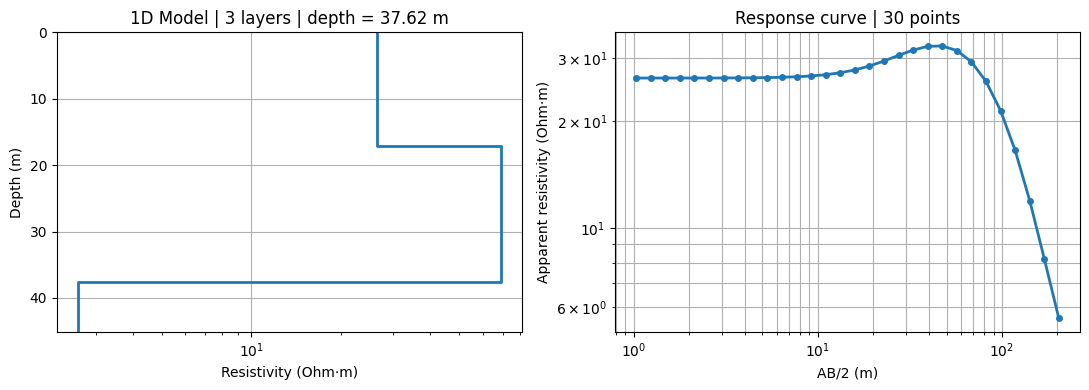

In [12]:
# PLOT ONE EXAMPLE

i = np.random.randint(0, N_MODELS)

nlay = n_layers_all[i]
nab2 = n_ab2_all[i]

res_ex = resistivities_all[i, :nlay]
thk_ex = thicknesses_all[i, :nlay - 1]
ab2_ex = ab2_all[i, :nab2]
rho_ex = rho_app_all[i, :nab2]
depth_ex = total_depth_all[i]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plot_model(axes[0], res_ex, thk_ex)
axes[0].set_title(f"1D Model | {nlay} layers | depth = {depth_ex:.2f} m")

axes[1].loglog(ab2_ex, rho_ex, 'o-', lw=2, ms=4)
axes[1].set_xlabel("AB/2 (m)")
axes[1].set_ylabel("Apparent resistivity (Ohm·m)")
axes[1].set_title(f"Response curve | {nab2} points")
axes[1].grid(True, which="both")

plt.tight_layout()
plt.show()